# 01 - Data Exploration: MIT-BIH Arrhythmia Database

**DSR Pipeline Phase: Problem Understanding & Data Acquisition**

This notebook explores the MIT-BIH Arrhythmia Database before any preprocessing.
We examine:
- The 48 records and their pathology categories
- AAMI annotation symbol grouping (Normal vs Anomalous)
- Class balance across the dataset
- Raw ECG signal visualization

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from ecg_anomaly.config import SystemConfig
from ecg_anomaly.data.registry import RecordRegistry, AAMI_NORMAL, AAMI_ANOMALOUS
from ecg_anomaly.data.loader import MITBIHLoader

sns.set_style("whitegrid")
config = SystemConfig.from_yaml("../config/default.yaml")
registry = RecordRegistry()

## 1. Record Catalog

MIT-BIH contains 48 records. We exclude 4 pacemaker records (102, 104, 107, 217)
following AAMI recommendations, leaving 44 usable records.

In [2]:
print(f"Total records in MIT-BIH: {len(RecordRegistry.ALL_RECORDS)}")
print(f"Excluded (pacemaker): {sorted(config.excluded_records)}")

valid_records = registry.get_valid_records(set(config.excluded_records))
print(f"Valid records for analysis: {len(valid_records)}")
print(f"Record IDs: {valid_records}")

Total records in MIT-BIH: 48
Excluded (pacemaker): ['102', '104', '107', '217']
Valid records for analysis: 44
Record IDs: ['100', '101', '103', '105', '106', '108', '109', '111', '112', '113', '114', '115', '116', '117', '118', '119', '121', '122', '123', '124', '200', '201', '202', '203', '205', '207', '208', '209', '210', '212', '213', '214', '215', '219', '220', '221', '222', '223', '228', '230', '231', '232', '233', '234']


## 2. Record Categories by Pathology

Records are grouped by their predominant arrhythmia type.

Record categories:

  Normal: 15 records -> ['100', '101', '103', '112', '113', '115', '116', '117', '121', '122', '123', '220', '230', '231', '232']
  PVC_Ventricular: 19 records -> ['105', '106', '108', '109', '119', '200', '201', '203', '205', '208', '210', '213', '214', '215', '219', '221', '228', '233', '234']
  APC_Atrial: 3 records -> ['209', '222', '223']
  Bloqueos: 5 records -> ['111', '118', '124', '207', '212']
  Mixto_Complejo: 2 records -> ['114', '202']


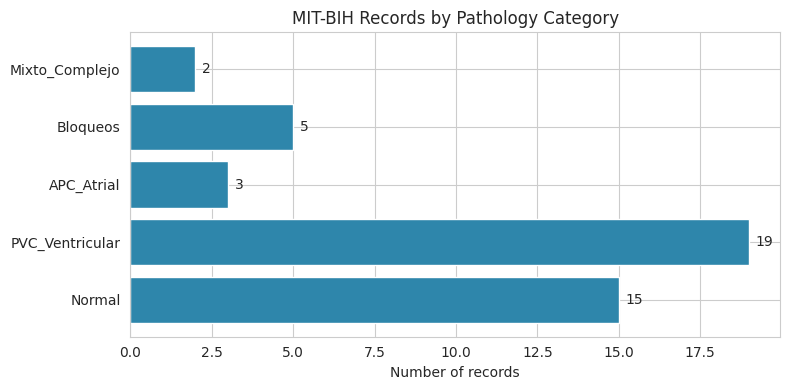

In [3]:
categories = registry.get_categories()
print("Record categories:\n")
for cat in categories:
    records = registry.get_records_by_category(cat)
    print(f"  {cat}: {len(records)} records -> {records}")

# Bar chart of category sizes
cat_sizes = {cat: len(registry.get_records_by_category(cat)) for cat in categories}
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(list(cat_sizes.keys()), list(cat_sizes.values()), color="#2E86AB")
ax.set_xlabel("Number of records")
ax.set_title("MIT-BIH Records by Pathology Category")
for i, v in enumerate(cat_sizes.values()):
    ax.text(v + 0.2, i, str(v), va="center")
plt.tight_layout()
plt.show()

## 3. AAMI Symbol Grouping

The AAMI standard groups MIT-BIH annotation symbols into clinically meaningful classes.
For binary anomaly detection we use:
- **Normal (0):** N, L, R, e, j
- **Anomalous (1):** A, a, J, S, V, E, F, /, f, Q

In [4]:
print("AAMI Normal symbols:", sorted(AAMI_NORMAL))
print("AAMI Anomalous symbols:", sorted(AAMI_ANOMALOUS))
print()
print("Example classifications:")
for sym in ["N", "L", "R", "V", "A", "F", "/", "+", "~"]:
    label = RecordRegistry.classify_symbol(sym)
    desc = {0: "Normal", 1: "Anomalous", -1: "Non-beat (ignored)"}[label]
    print(f"  '{sym}' -> {label} ({desc})")

AAMI Normal symbols: ['L', 'N', 'R', 'e', 'j']
AAMI Anomalous symbols: ['/', 'A', 'E', 'F', 'J', 'Q', 'S', 'V', 'a', 'f']

Example classifications:
  'N' -> 0 (Normal)
  'L' -> 0 (Normal)
  'R' -> 0 (Normal)
  'V' -> 1 (Anomalous)
  'A' -> 1 (Anomalous)
  'F' -> 1 (Anomalous)
  '/' -> 1 (Anomalous)
  '+' -> -1 (Non-beat (ignored))
  '~' -> -1 (Non-beat (ignored))


## 4. Load Dataset and Examine Class Balance

In [5]:
loader = MITBIHLoader(config)
dataset = loader.load(config.dataset_path)

print(f"Records loaded: {len(dataset.records)}")
print(f"Total beats: {dataset.total_beats:,}")
print(f"Normal beats: {dataset.total_normal:,} ({dataset.total_normal/dataset.total_beats*100:.1f}%)")
print(f"Anomalous beats: {dataset.total_anomalous:,} ({dataset.total_anomalous/dataset.total_beats*100:.1f}%)")

Records loaded: 44
Total beats: 100,733
Normal beats: 90,125 (89.5%)
Anomalous beats: 10,608 (10.5%)


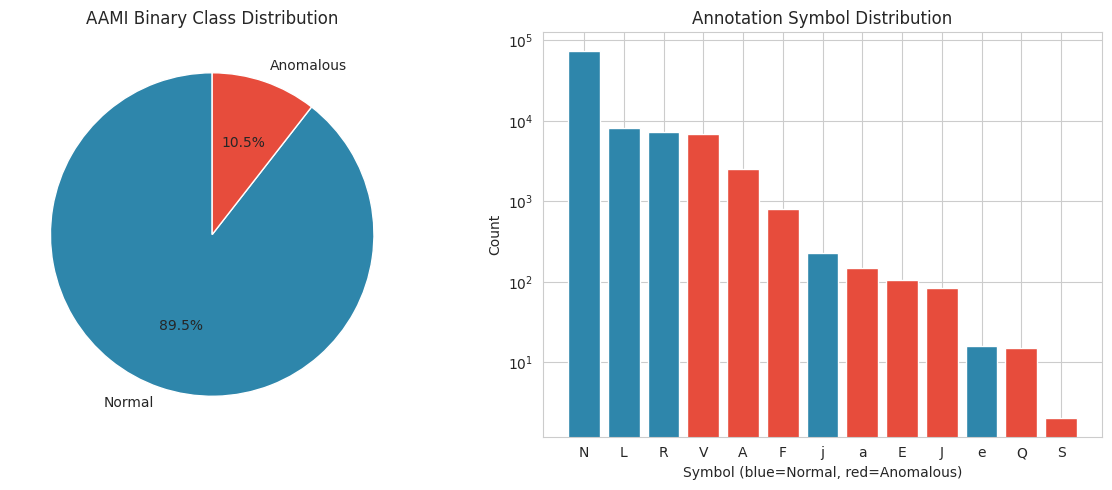

In [6]:
# Global class balance pie chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
axes[0].pie(
    [dataset.total_normal, dataset.total_anomalous],
    labels=["Normal", "Anomalous"],
    colors=["#2E86AB", "#E74C3C"],
    autopct="%1.1f%%",
    startangle=90,
)
axes[0].set_title("AAMI Binary Class Distribution")

# Symbol distribution across all records
all_symbols = []
for rec in dataset.records:
    all_symbols.extend(rec.symbols.tolist())

symbol_counts = Counter(all_symbols)
symbols_sorted = sorted(symbol_counts.items(), key=lambda x: -x[1])
syms, counts = zip(*symbols_sorted)
colors = ["#2E86AB" if s in AAMI_NORMAL else "#E74C3C" for s in syms]

axes[1].bar(syms, counts, color=colors)
axes[1].set_ylabel("Count")
axes[1].set_title("Annotation Symbol Distribution")
axes[1].set_yscale("log")
axes[1].set_xlabel("Symbol (blue=Normal, red=Anomalous)")

plt.tight_layout()
plt.show()

## 5. Per-Record Class Balance

Some records are predominantly normal, others contain many arrhythmias.

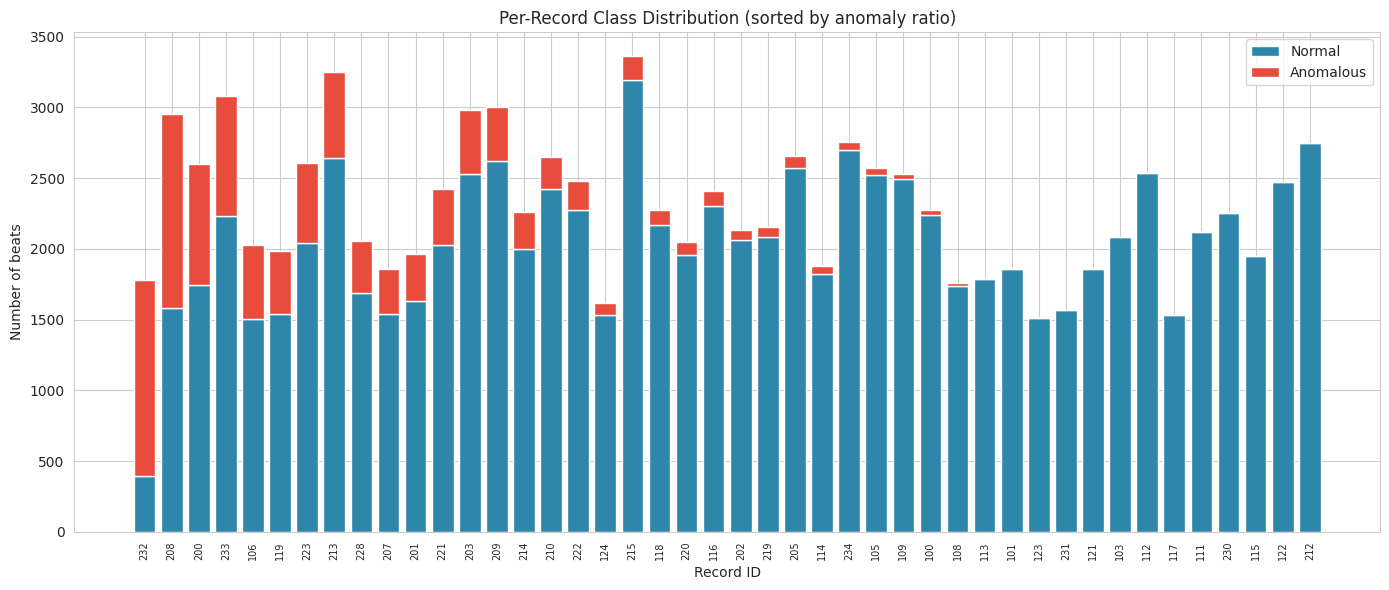

In [7]:
record_stats = []
for rec in dataset.records:
    n_normal = int(np.sum(rec.binary_labels == 0))
    n_anomalous = int(np.sum(rec.binary_labels == 1))
    record_stats.append((rec.record_id, n_normal, n_anomalous))

record_stats.sort(key=lambda x: x[2] / (x[1] + x[2]), reverse=True)

fig, ax = plt.subplots(figsize=(14, 6))
ids = [r[0] for r in record_stats]
normals = [r[1] for r in record_stats]
anomalous = [r[2] for r in record_stats]

ax.bar(ids, normals, label="Normal", color="#2E86AB")
ax.bar(ids, anomalous, bottom=normals, label="Anomalous", color="#E74C3C")
ax.set_xlabel("Record ID")
ax.set_ylabel("Number of beats")
ax.set_title("Per-Record Class Distribution (sorted by anomaly ratio)")
ax.legend()
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

## 6. Raw ECG Signal Visualization

Visualize a few seconds of raw signal from selected records.

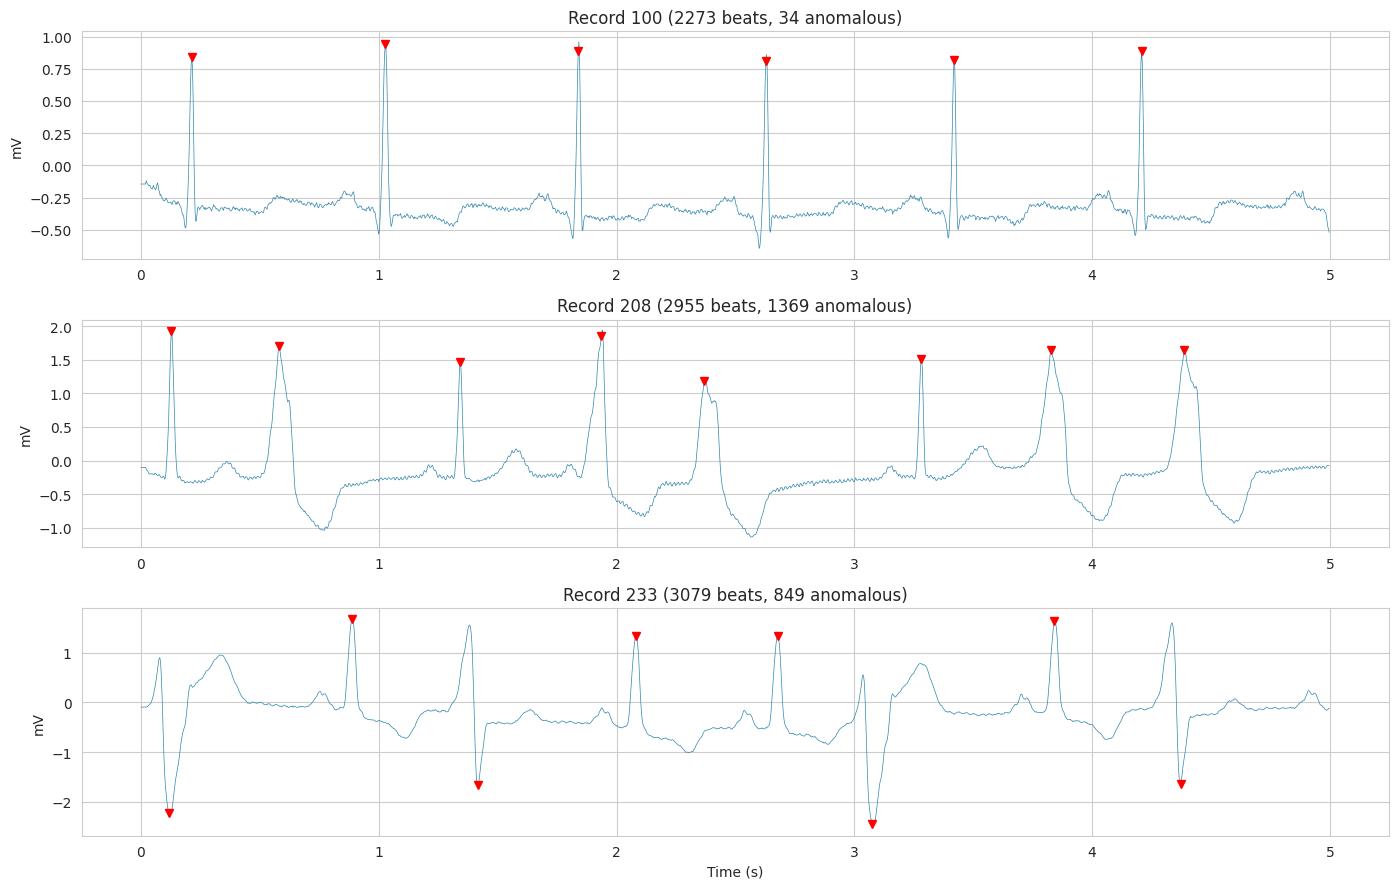

In [8]:
# Pick 3 records: one normal-dominant, one with many anomalies, one mixed
sample_ids = ["100", "233", "208"]
sample_records = [r for r in dataset.records if r.record_id in sample_ids]

fig, axes = plt.subplots(len(sample_records), 1, figsize=(14, 3 * len(sample_records)))
if len(sample_records) == 1:
    axes = [axes]

for ax, rec in zip(axes, sample_records):
    duration = 5  # seconds
    n_samples = duration * rec.sampling_rate
    t = np.arange(min(n_samples, len(rec.signal))) / rec.sampling_rate
    sig = rec.signal[:len(t)]

    ax.plot(t, sig, linewidth=0.5, color="#2E86AB")

    # Mark R-peaks in this window
    peaks_in_window = rec.r_peak_positions[rec.r_peak_positions < len(t)]
    ax.plot(peaks_in_window / rec.sampling_rate, sig[peaks_in_window], "rv", markersize=6)

    n_anom = int(np.sum(rec.binary_labels == 1))
    ax.set_title(f"Record {rec.record_id} ({len(rec.binary_labels)} beats, {n_anom} anomalous)")
    ax.set_ylabel("mV")

axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

## Summary

Key observations:
- The dataset is **class-imbalanced**: normal beats significantly outnumber anomalous ones.
- The dominant symbol is 'N' (normal sinus); 'V' (PVC) and 'A' (APC) are the most common anomalies.
- Some records contain almost exclusively normal beats, while others are arrhythmia-heavy.
- This imbalance is a key challenge for unsupervised anomaly detection.

**Next:** `02_preprocessing.ipynb` -- filter, segment, and normalize the signals.